<a href="https://colab.research.google.com/github/NegasaReta/Elevvo-Internship-Machine-Learning-Track/blob/Task-2/Task_4_Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    f1_score
)

In [4]:
df = pd.read_csv('/content/loan_approval_dataset.csv')

In [5]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [7]:
df = df.copy()
df.columns = df.columns.str.strip()

In [8]:
df.columns


Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [10]:
TARGET = "loan_status"
ID_COL = "loan_id"
if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found. Columns: {df.columns.tolist()}")

In [11]:
# Drop ID column (not predictive; can cause leakage-like behavior)
X = df.drop(columns=[TARGET] + ([ID_COL] if ID_COL in df.columns else []))
y_raw = df[TARGET]

In [13]:
if y_raw.dtype == "object":
    # Try common mappings; adjust if your dataset uses different strings
    mapping_candidates = [
        {"Approved": 1, "Rejected": 0},
        {"Y": 1, "N": 0},
        {"Yes": 1, "No": 0},
        {"1": 1, "0": 0},
    ]
    y = None
    # Strip whitespace from y_raw before attempting to map
    y_raw_stripped = y_raw.str.strip()
    for mp in mapping_candidates:
        y_try = y_raw_stripped.map(mp)
        if not y_try.isna().any():
            y = y_try.astype(int)
            break
    if y is None:
        raise ValueError(
            f"Couldn't map target values automatically. Unique values: {y_raw.unique()}"
        )
else:
    y = y_raw.astype(int)

In [14]:
print("Class distribution (loan_status):")
display(y.value_counts())
display((y.value_counts(normalize=True) * 100).round(2).rename("%"))
print("-" * 60)

Class distribution (loan_status):


,count
loan_status,
1,2656
0,1613


,%
loan_status,
1,62.22
0,37.78


------------------------------------------------------------


In [15]:
# 2) Feature types
# ==========================================
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print("-" * 60)


Numeric features (9): ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical features (2): ['education', 'self_employed']
------------------------------------------------------------


# 3) Preprocessing pipeline

In [16]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# 4) Train/test split (stratified for imbalance)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print("-" * 60)

Train shape: (3415, 11) | Test shape: (854, 11)
------------------------------------------------------------


# 5) Models (imbalance-aware via class_weight)

Training LogReg (balanced) ...

✅ LogReg (balanced)
              precision    recall  f1-score   support

           0     0.8772    0.9288    0.9023       323
           1     0.9551    0.9209    0.9377       531

    accuracy                         0.9239       854
   macro avg     0.9161    0.9248    0.9200       854
weighted avg     0.9256    0.9239    0.9243       854



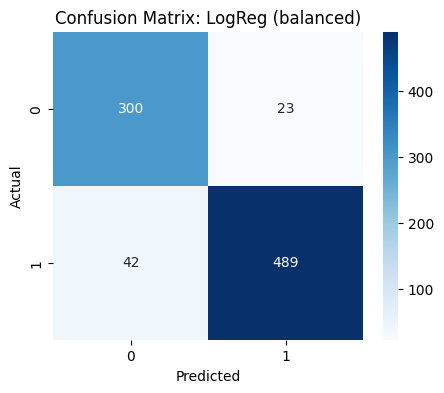

🎯 Precision (Approved=1): 0.9551
🎯 Recall    (Approved=1): 0.9209
🎯 F1-score  (Approved=1): 0.9377
Training RandomForest (balanced) ...

✅ RandomForest (balanced)
              precision    recall  f1-score   support

           0     0.9813    0.9752    0.9783       323
           1     0.9850    0.9887    0.9868       531

    accuracy                         0.9836       854
   macro avg     0.9831    0.9820    0.9826       854
weighted avg     0.9836    0.9836    0.9836       854



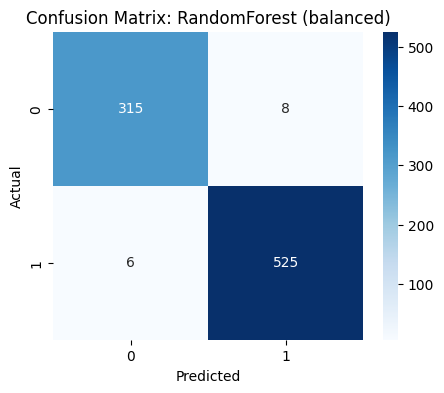

🎯 Precision (Approved=1): 0.9850
🎯 Recall    (Approved=1): 0.9887
🎯 F1-score  (Approved=1): 0.9868


In [20]:
models = {
    "LogReg (balanced)": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "RandomForest (balanced)": RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
}

def evaluate(name, pipe, X_test, y_test, positive_label=1):
    y_pred = pipe.predict(X_test)

    print(f"\n==============================")
    print(f"✅ {name}")
    print(f"==============================")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    # Focus metric: F1 for positive class (loan approved = 1)
    f1_pos = f1_score(y_test, y_pred, pos_label=positive_label)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", pos_label=positive_label
    )

    print(f"🎯 Precision (Approved=1): {precision:.4f}")
    print(f"🎯 Recall    (Approved=1): {recall:.4f}")
    print(f"🎯 F1-score  (Approved=1): {f1_pos:.4f}")

    return {
        "model": name,
        "precision(Approved=1)": precision,
        "recall(Approved=1)": recall,
        "f1(Approved=1)": f1_pos
    }

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    print(f"Training {name} ...")
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    results.append(evaluate(name, pipe, X_test, y_test))


In [21]:
leaderboard = pd.DataFrame(results).sort_values("f1(Approved=1)", ascending=False)
print("\nLeaderboard (sorted by F1 for Approved=1)")
display(leaderboard)


Leaderboard (sorted by F1 for Approved=1)


,model,precision(Approved=1),recall(Approved=1),f1(Approved=1)
1,RandomForest (balanced),0.984991,0.988701,0.986842
0,LogReg (balanced),0.955078,0.920904,0.937680
